### 第十二章 使用 Pandas 處理數據資料

#### 12.1 一維的 Series

##### 12.1.1 建立 Series

In [1]:
import pandas as pd

In [2]:
s1 = pd.Series([4.3, 7.24, 8.5])

In [3]:
s1

0    4.30
1    7.24
2    8.50
dtype: float64

In [4]:
s2 = pd.Series({'a':5,'b':2,'c':3})

In [5]:
s2

a    5
b    2
c    3
dtype: int64

In [6]:
s3 = pd.Series([4.3, 7.24, 8.5], 
     index = ['A', 'B', 'C'])

In [7]:
s3

A    4.30
B    7.24
C    8.50
dtype: float64

##### 12.1.2 Series 常用的查詢及缺失值處理

In [8]:
s1 = pd.Series([4, 7, 8])

In [9]:
s1.size

3

In [10]:
s1.dtypes

dtype('int64')

In [11]:
s1.values

array([4, 7, 8])

In [12]:
s1.index

RangeIndex(start=0, stop=3, step=1)

In [13]:
s2 = pd.Series([4.3, 7.24, 8.5])

In [14]:
s2[1]

np.float64(7.24)

In [15]:
s2[1:]

1    7.24
2    8.50
dtype: float64

In [16]:
s2[4]=6; s2

0    4.30
1    7.24
2    8.50
4    6.00
dtype: float64

In [17]:
s3 = pd.Series([4, 7, 8],
     index=['a', 'b', 'c'])

In [18]:
s3['a']

np.int64(4)

In [19]:
d1 = {'cat':5, 'dog':3, 'fox':6}
s4 = pd.Series(d1)

In [20]:
'ant' in s4

False

In [21]:
3 in s4

False

In [23]:
s4.where(s4 > 4)

cat    5.0
dog    NaN
fox    6.0
dtype: float64

In [22]:
s5 = pd.Series(d1,
     index=['dog', 'bat', 'cat'])

In [23]:
s5

dog    3.0
bat    NaN
cat    5.0
dtype: float64

In [24]:
s5.isna()

dog    False
bat     True
cat    False
dtype: bool

In [25]:
s5.index = ['dog', 'fox', 'rat']

In [26]:
s5

dog    3.0
fox    NaN
rat    5.0
dtype: float64

In [27]:
s5.fillna(0)

dog    3.0
fox    0.0
rat    5.0
dtype: float64

In [28]:
s5.dropna()

dog    3.0
rat    5.0
dtype: float64

In [29]:
# ch12_1.py, 計算成績平均
import pandas as pd  
scores = pd.Series({'Math':80, 'English':63, 'Biology':92})
total_score = 0                         		# 總分

for subject, score in scores.items():
    total_score += score                		# 計算加總
    print(f"{subject}: {score}")       		# 印出科目和分數
average_score = total_score / scores.size 	# 計算平均分數
print(f'平均: {average_score:.2f}')         	# 印出結果

Math: 80
English: 63
Biology: 92
平均: 78.33


#### 12.2 二維的 DataFrame

##### 12.2.1 建立 DataFrame

In [30]:
import pandas as pd
import numpy as np

In [31]:
ar = np.arange(6).reshape((2, 3))
pd.DataFrame(ar)

,0,1,2
0,0,1,2
1,3,4,5


In [32]:
pd.DataFrame(ar, columns=['a', 'b', 'c'])

,a,b,c
0,0,1,2
1,3,4,5


In [33]:
pd.DataFrame(ar, index=['Java', 'C++'])

,0,1,2
Java,0,1,2
C++,3,4,5


##### 12.2.2 DataFrame 常用的函數

In [34]:
data = {'Math':[98, 99, 38],
        'Bio':[89, 45, 67],
        'Eng':[87, 98, 98]}

In [35]:
pd.DataFrame(data, 
   columns=['Eng', 'Math', 'Bio'])

,Eng,Math,Bio
0,87,98,89
1,98,99,45
2,98,38,67


In [36]:
d1 = pd.DataFrame(data, 
     columns=['Eng', 'Math', 'Art'], 
     index = ['Tom', 'Jerry', 'Mary'])

In [37]:
d1

,Eng,Math,Art
Tom,87,98,NaN
Jerry,98,99,NaN
Mary,98,38,NaN


In [39]:
d2 = pd.DataFrame(
    [[63, 65, 77], [63, None, 39]],
    columns=['Java','C++','VB']); d2

,Java,C++,VB
0,63,65.0,77
1,63,NaN,39


In [40]:
d2['C++'][1]

np.float64(nan)

In [41]:
d2.isna()

,Java,C++,VB
0,False,False,False
1,False,True,False


In [42]:
d2.where(d2 < 60)

,Java,C++,VB
0,NaN,NaN,NaN
1,NaN,NaN,39.0


In [43]:
# ch12_2.py, 寵物資訊管理
import pandas as pd  
data = {'Name': ['Luna', 'Mimi', 'Coco'],
        'Type': ['狗', '貓', '兔'],
        'Age': [3, None, 5],            # Mimi的年齡缺失
        'Weight': [None, 4.3, 2.6]}    # Luna的體重缺失
df = pd.DataFrame(data) 		# 建立DataFrame，其中部分數據缺失
print("原始寵物資料：")
print(df.to_string())

if df['Age'].isna().all():
    df['Age'] = 0       		# 如果整欄都是NaN，就用0
else:
    df['Age'] = df['Age'].fillna(df['Age'].mean())

if df['Weight'].isna().all():
    df['Weight'] = 0    		# 如果整欄都是NaN，就用0
else:
    df['Weight'] = df['Weight'].fillna(df['Weight'].mean())

print("\n填補缺失值後的寵物資料：")     # 處理後的DataFrame
print(df.to_string()) 

原始寵物資料：
   Name Type  Age  Weight
0  Luna    狗  3.0     NaN
1  Mimi    貓  NaN     4.3
2  Coco    兔  5.0     2.6

填補缺失值後的寵物資料：
   Name Type  Age  Weight
0  Luna    狗  3.0    3.45
1  Mimi    貓  4.0    4.30
2  Coco    兔  5.0    2.60


#### 12.3 Pandas 的元素操作與運算

##### 12.3.1 元素的選取

In [44]:
s1 = pd.Series([6, 7, 8],
index=['a', 'b', 'c']);

In [45]:
s1

a    6
b    7
c    8
dtype: int64

In [46]:
s1['c'], s1.loc['c']

(np.int64(8), np.int64(8))

In [47]:
s1.iloc[-1], s1.iloc[2]

(np.int64(8), np.int64(8))

In [48]:
d1 = pd.DataFrame(
     np.arange(6).reshape(2, 3), 
     index=['a', 'b'], 
     columns=['x', 'y', 'z']);

In [49]:
d1

,x,y,z
a,0,1,2
b,3,4,5


In [50]:
d1.loc['a', 'z']

np.int64(2)

In [51]:
d1.iloc[1,2]

np.int64(5)

In [52]:
d1.loc['a', ['y', 'x']]

y    1
x    0
Name: a, dtype: int64

In [53]:
d1.loc[['b', 'a'], ['x', 'z']]

,x,z
b,3,5
a,0,2


In [54]:
d1.iloc[:2, 1:]

,y,z
a,1,2
b,4,5


In [56]:
# ch12_3.py, 茶葉重量價格查詢
import pandas as pd
df = pd.DataFrame({				# 建立 DataFrame
    '100g': [300, 425, 450],
    '150g': [400, 612, 824],
    '200g': [750, 830, 1399]
}, index=['Black Tea', 'Green Tea', 'OolongTea'])

def query_price(tea: str, weight: str):
    price = df.loc[tea, weight]  	# 直接從DataFrame查詢
    print(f"{tea}, {weight} 價格是 {price}")
    return price

query_price("Green Tea", "100g")  	# 測試查詢
query_price("Black Tea", "200g")   	# 測試查詢
query_price("OolongTea", "150g")   	# 測試查詢

Green Tea, 100g 價格是 425
Black Tea, 200g 價格是 750
OolongTea, 150g 價格是 824


np.int64(824)

In [57]:
d2 = pd.DataFrame(
    np.arange(8).reshape(2, 4),
    index = ['a', 'b'], 
    columns = ['w', 'x', 'y', 'z']);

In [58]:
d2[['w', 'y', 'x']]

,w,y,x
a,0,2,1
b,4,6,5


In [59]:
d2.loc[['b'], ['x', 'z']]

,x,z
b,5,7


In [60]:
d2[0:1][['x', 'z']]

,x,z
a,1,3


##### 12.3.2 條件篩選元素

In [61]:
s1 = pd.Series([23, 55, 32])

In [62]:
s1[s1 < 40]

0    23
2    32
dtype: int64

In [63]:
score = [[37, 65, 54], [38, 87, 77]]
name = ['Tom', 'Jerry']
course = ['Math', 'Eng', 'Bio']

In [64]:
d1 = pd.DataFrame(score,
     index = name, columns = course)

In [65]:
d1

,Math,Eng,Bio
Tom,37,65,54
Jerry,38,87,77


In [66]:
d1[d1['Bio'] >= 60]

,Math,Eng,Bio
Jerry,38,87,77


In [67]:
d1 >= 60

,Math,Eng,Bio
Tom,False,True,False
Jerry,False,True,True


In [68]:
d1.loc['Jerry'] >= 60

Math    False
Eng      True
Bio      True
Name: Jerry, dtype: bool

In [69]:
d1.columns[d1.loc['Jerry'] >= 60]

Index(['Eng', 'Bio'], dtype='object')

In [70]:
d1.index[d1['Math'] < 60]

Index(['Tom', 'Jerry'], dtype='object')

In [71]:
(d1 >= 60).all(axis = 1)

Tom      False
Jerry    False
dtype: bool

In [72]:
(d1.Math < 60) | (d1.Bio < 60)

Tom      True
Jerry    True
dtype: bool

In [73]:
# ch12_4.py, 動物資料篩選
import pandas as pd
data={'Weight': [4.5, 8.0, 1.2, 2.3, 0.3],
      'Species': ['Cat', 'Dog', 'Rabbit', 'Turtle', 'Bird'],
      'Adopted': [False, True, False, False, True]}

names = ['Tom', 'Max', 'Leo', 'Sam', 'Ben']
df = pd.DataFrame(data, index=names)    # 建立DataFrame

print('動物資料:\n', df)
# 篩選體重小於2公斤且未被領養的動物
result = df[(df['Weight'] < 2) & (df['Adopted'] == False)]
print('\n體重小於2公斤且未被領養的動物:\n', result)

動物資料:
      Weight Species  Adopted
Tom     4.5     Cat    False
Max     8.0     Dog     True
Leo     1.2  Rabbit    False
Sam     2.3  Turtle    False
Ben     0.3    Bird     True

體重小於2公斤且未被領養的動物:
      Weight Species  Adopted
Leo     1.2  Rabbit    False


##### 12.3.3 索引的重排與資料分組

In [74]:
s1 = pd.Series([8, 1], index = ['c', 'a'])

In [75]:
s1

c    8
a    1
dtype: int64

In [76]:
s1.reindex(['a', 'b', 'c'])

a    1.0
b    NaN
c    8.0
dtype: float64

In [78]:
d1=pd.DataFrame([[1, 2, 3], [4, 5, 6]],
    index = ['a', 'b'],
    columns = ['x', 'y', 'z'])

In [79]:
d1

,x,y,z
a,1,2,3
b,4,5,6


In [80]:
d1.reindex(list('abc'))

,x,y,z
a,1.0,2.0,3.0
b,4.0,5.0,6.0
c,NaN,NaN,NaN


In [81]:
d1.reindex(columns = ['x', 'y', 'w'])

,x,y,w
a,1,2,NaN
b,4,5,NaN


In [82]:
data={'Group':['A','B','A','B','B'],
      'Value':[10,20,30,40,50],
      'Rate':[85,92,85,85,92]}

In [83]:
d2 = pd.DataFrame(data)

In [84]:
d2

,Group,Value,Rate
0,A,10,85
1,B,20,92
2,A,30,85
3,B,40,85
4,B,50,92


In [85]:
gp1 = d2.groupby('Rate')

In [86]:
for name, group in gp1:
    print(f'Rate: {name}')
    print(group)

Rate: 85
  Group  Value  Rate
0     A     10    85
2     A     30    85
3     B     40    85
Rate: 92
  Group  Value  Rate
1     B     20    92
4     B     50    92


In [87]:
gp2 = d2.groupby(['Group', 'Rate'],)

In [88]:
for name, group in gp2:
    print(f'Group: {name}')
    print(group)


Group: ('A', np.int64(85))
  Group  Value  Rate
0     A     10    85
2     A     30    85
Group: ('B', np.int64(85))
  Group  Value  Rate
3     B     40    85
Group: ('B', np.int64(92))
  Group  Value  Rate
1     B     20    92
4     B     50    92


In [89]:
# ch12_5.py, 動物醫療資料的索引與分組
import pandas as pd
# 建立動物醫療資料
data={'Species': ['Cat', 'Dog', 'Dog', 'Rabbit', 'Turtle'],
      'Weight': [4.2, 9.1, 7.8, 1.3, 2.4],
      'Health': ['良好', '中等', '良好', '差', '良好']}
index=['小花', '阿毛', '阿呆', '球球', '小龜']
df = pd.DataFrame(data, index=index)

# 重新指定索引順序
new_order = ['阿呆', '小花', '球球', '阿毛', '小龜']
df_reindex = df.reindex(new_order)
print("重新指定索引順序後的資料：")
print(df_reindex)

# 依健康狀況分組
group = df.groupby('Health', as_index=False)
print("\n依健康狀況分組後的資料：")
for health, group_data in group:
    print(f"健康狀況: {health}")
    print(group_data)

重新指定索引順序後的資料：
   Species  Weight Health
阿呆     Dog     7.8     良好
小花     Cat     4.2     良好
球球  Rabbit     1.3      差
阿毛     Dog     9.1     中等
小龜  Turtle     2.4     良好

依健康狀況分組後的資料：
健康狀況: 中等
   Species  Weight Health
阿毛     Dog     9.1     中等
健康狀況: 差
   Species  Weight Health
球球  Rabbit     1.3      差
健康狀況: 良好
   Species  Weight Health
小花     Cat     4.2     良好
阿呆     Dog     7.8     良好
小龜  Turtle     2.4     良好


##### 12.3.4 刪除與插入列或欄

In [90]:
s1 = pd.Series([2, 4, 6])

In [91]:
s1.drop([1, 0])

2    6
dtype: int64

In [92]:
pd.concat([s1, pd.Series([7, 9])])

0    2
1    4
2    6
0    7
1    9
dtype: int64

In [93]:
pd.concat([s1,pd.Series([7, 9])],
ignore_index = True)

0    2
1    4
2    6
3    7
4    9
dtype: int64

In [94]:
d1 = pd.DataFrame([[1, 2, 3], [4, 5, 6]])

In [95]:
d1.drop([0, 1], axis = 1)

,2
0,3
1,6


In [96]:
d1

,0,1,2
0,1,2,3
1,4,5,6


In [97]:
pd.concat([d1,
    pd.DataFrame([[9, 9, 9]])])

,0,1,2
0,1,2,3
1,4,5,6
0,9,9,9


In [98]:
d1.drop([0, 1], axis = 1, inplace = True)

In [99]:
d1

,2
0,3
1,6


In [100]:
d2 = pd.DataFrame([[1, 2], [3, 4]],
     index = ['a', 'b'],
     columns = ['x', 'y'])

In [101]:
d2

,x,y
a,1,2
b,3,4


In [102]:
d2.insert(1, 'v', [9, 8])

In [103]:
d2

,x,v,y
a,1,9,2
b,3,8,4


In [104]:
# ch12_6.py，刪除與插入列或欄
import pandas as pd
data={'Species': ['Cat', 'Dog'], 			# 建立資料表
      'Weight': [4.2, 9.1],
      'Health': ['Good', 'Poor']}
index = ['CoCo', 'Toby']
df=pd.DataFrame(data, index=index)
print(f"原始資料：")
print(df)

df.drop(columns='Health', inplace=True) 	# 刪除 健康 欄
print("\n刪除 Health 欄後：")
print(df)

df.insert(1, 'Age', [3, 5]) 				# 插入新的欄位 年齡
print("\n插入 Age 欄後：")
print(df)

原始資料：
     Species  Weight Health
CoCo     Cat     4.2   Good
Toby     Dog     9.1   Poor

刪除 Health 欄後：
     Species  Weight
CoCo     Cat     4.2
Toby     Dog     9.1

插入 Age 欄後：
     Species  Age  Weight
CoCo     Cat    3     4.2
Toby     Dog    5     9.1


##### 12.3.5 常用的四則運算函數

In [105]:
s1 = pd.Series([2, 9, 1],
     index = ['a', 'c', 'd'])

In [106]:
s2 = pd.Series([3, 2], index = ['a', 'd'])

In [107]:
s1.add(s2)

a    5.0
c    NaN
d    3.0
dtype: float64

In [108]:
s1.add(s2, fill_value = 0) 

a    5.0
c    9.0
d    3.0
dtype: float64

In [109]:
s3 = pd.concat([s1, s2]); s3

a    2
c    9
d    1
a    3
d    2
dtype: int64

In [110]:
s3['a']

a    2
a    3
dtype: int64

In [111]:
s3[~s3.index.duplicated()]

a    2
c    9
d    1
dtype: int64

In [112]:
d1 = pd.DataFrame([[2, 3], [4, 5]],
     columns = ['a', 'b'],
     index = ['x', 'y'])

In [113]:
d1

,a,b
x,2,3
y,4,5


In [114]:
d2 = pd.DataFrame([[6, 7, 8], [9, 0, 1]],
     columns = ['a', 'b', 'c'],
     index = ['x', 'y'])

In [115]:
d2

,a,b,c
x,6,7,8
y,9,0,1


In [116]:
d1.add(d2, fill_value = 0)

,a,b,c
x,8,10,8.0
y,13,5,1.0


In [117]:
np.average(d2, axis = 0)

array([7.5, 3.5, 4.5])

In [118]:
np.sum(d2, axis = 1)

x    21
y    10
dtype: int64

In [119]:
# ch12_7.py, 計算各科成績的平均值
import pandas as pd 
import numpy as np 
data = {'Math':[98, 96, 39],
         'Biology':[78, 89, 45],
         'English':[87, 98, 66]}

d0=pd.DataFrame(data,index=['Tom', 'Leo', 'Ava'])
print(d0)  							# 顯示所有學生的各科成績

mat_avg = round(np.mean(d0['Math']), 2)     		# 計算數學平均
bio_avg = round(np.mean(d0['Biology']), 2)  	# 計算生物平均
eng_avg = round(np.mean(d0['English']), 2)  	# 計算英文平均
# 印出每科的平均值
print(f'平均 {mat_avg:6.1f}{bio_avg:9.1f}{eng_avg:9.1f}')

     Math  Biology  English
Tom    98       78       87
Leo    96       89       98
Ava    39       45       66
平均   77.7     70.7     83.7


#### 12.4 排序與統計函數

##### 12.4.1 排序函數

In [120]:
d1 = pd.DataFrame(
     [[40, 60, 50], [50, 70, 62]],
     columns = ['S', 'L', 'M'],
     index = ['tea', 'coffee'])

In [121]:
d1

,S,L,M
tea,40,60,50
coffee,50,70,62


In [122]:
d1.sort_index()

,S,L,M
coffee,50,70,62
tea,40,60,50


In [123]:
d1.sort_values(by = 'L', ascending = False)

,S,L,M
coffee,50,70,62
tea,40,60,50


In [124]:
d1.sort_values(by = 'coffee', axis = 1)

,S,M,L
tea,40,50,60
coffee,50,62,70


##### 12.4.2 統計函數

In [125]:
d1 = pd.DataFrame(
     [[3, 5, 7], [8, 9, 12]],
     index = ['x', 'y'],
     columns = ['a', 'b', 'c'])

In [126]:
d1

,a,b,c
x,3,5,7
y,8,9,12


In [127]:
d1.describe()

,a,b,c
count,2.000000,2.000000,2.000000
mean,5.500000,7.000000,9.500000
std,3.535534,2.828427,3.535534
min,3.000000,5.000000,7.000000
25%,4.250000,6.000000,8.250000
50%,5.500000,7.000000,9.500000
75%,6.750000,8.000000,10.750000
max,8.000000,9.000000,12.000000


In [128]:
d1.sum(axis = 1)

x    15
y    29
dtype: int64

In [129]:
d1.mean().mean()

np.float64(7.333333333333333)

In [130]:
d2 = pd.DataFrame(
     [[3, 5, None], [8, 6, 3]],
     index = ['x', 'y'],
     columns = ['a', 'b', 'c'])

In [131]:
d2

,a,b,c
x,3,5,NaN
y,8,6,3.0


In [132]:
d2.count(axis = 1)

x    2
y    3
dtype: int64

In [133]:
d2.sum(skipna = False, axis = 1) 

x     NaN
y    17.0
dtype: float64

In [134]:
# ch12_8.py, 統計不同品牌汽車的月銷售資料
import pandas as pd
data = {
    'Toyota': 97077,     
    'Honda': 23692,        
    'Nissan': 17397,    
    'Mitsubishi': 13932}
df = pd.DataFrame(data, index=['Total']).T

df['Avg_Month'] = df['Total'] // 12	# 計算平均月銷量
total_sales = df['Total'].sum()		# 計算所有車子總銷量

# 計算佔有率
df['Share%'] = ((df['Total'] / total_sales) * 100).round(2)
print(df)

            Total  Avg_Month  Share%
Toyota      97077       8089   63.83
Honda       23692       1974   15.58
Nissan      17397       1449   11.44
Mitsubishi  13932       1161    9.16


#### 12.5 Pandas 的繪圖

In [135]:
s1 = pd.Series([55, 30, 45],
     index = ['coffee', 'tea', 'juice'])

<Axes: title={'center': 'Sales'}, ylabel='June'>

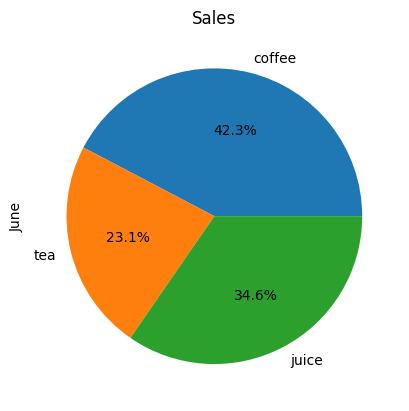

In [136]:
s1.plot(kind='pie', 
    autopct='%1.1f%%',
    title='Sales',
    label='June')

In [137]:
d1 = pd.DataFrame(
     [[50, 60, 80], [45, 70, 85]],
     columns = ['S', 'M', 'L'],
     index = ['red', 'green'])

In [138]:
d1

,S,M,L
red,50,60,80
green,45,70,85


<Axes: xlabel='Color', ylabel='Price'>

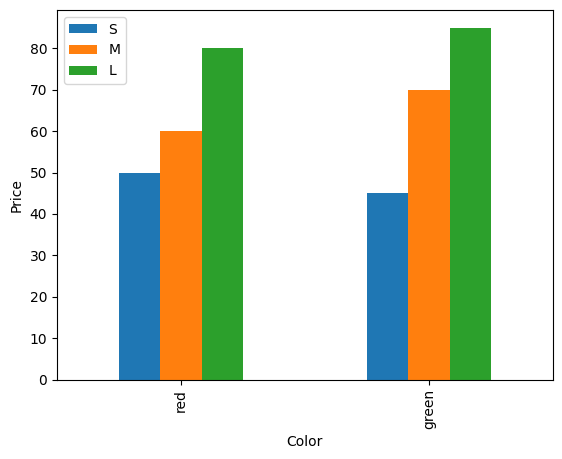

In [139]:
d1.plot(kind = 'bar',
xlabel = 'Color', ylabel = 'Price')

#### 12.6 存取 csv 檔與 pickle 檔

In [140]:
d1 = pd.DataFrame(
     [[50, 60, 80], [45, 70, 85]],
     columns = ['S', 'M', 'L'],
     index = ['red', 'green'])

In [141]:
d1

,S,M,L
red,50,60,80
green,45,70,85


In [142]:
d1.to_csv('price.csv')

In [143]:
!more price.csv

,S,M,L
red,50,60,80
green,45,70,85


In [144]:
pd.read_csv('price.csv', index_col = 0)

,S,M,L
red,50,60,80
green,45,70,85


In [145]:
d1.to_csv('price2.csv', header = None)

In [146]:
!more price2.csv

red,50,60,80
green,45,70,85


In [147]:
pd.read_csv('price2.csv', header=None, 
            names=['Color', 'S', 'M', 'L'])



,Color,S,M,L
0,red,50,60,80
1,green,45,70,85


In [150]:
d1.to_pickle('price3')

In [151]:
d2 = pd.read_pickle('price3')

In [152]:
d2

,S,M,L
red,50,60,80
green,45,70,85


In [153]:
d2.eq(d1)

,S,M,L
red,True,True,True
green,True,True,True


In [154]:
d2.eq(d1).all(axis = None)

np.True_